# TALLER N4
# SERIES DE TAYLOR

Grafique las curvas de las series de Taylor de varios órdenes para los siguientes casos:

cos(x),x0=0

In [1]:
import sympy as sp 

x = sp.symbols('x')

f=sp.cos(x)

df = sp.diff(f, x)

fdd = sp.diff(df, x)

fddd= sp.diff(fdd, x)

print("f(x) =", f)
print("f'(x) =", df)
print("f''(x) =", fdd)
print("f'''(x) =", fddd)

f(x) = cos(x)
f'(x) = -sin(x)
f''(x) = -cos(x)
f'''(x) = sin(x)


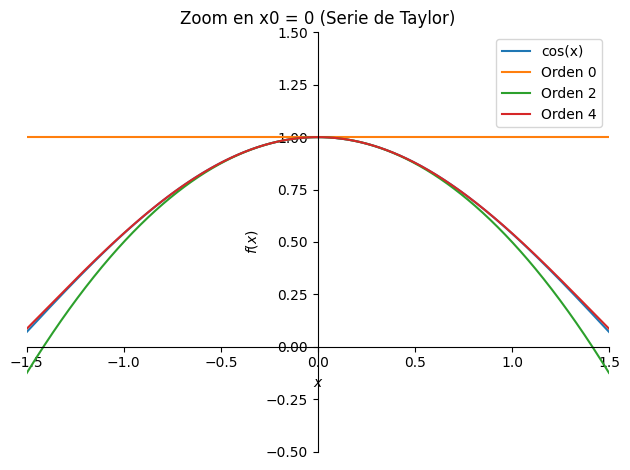

In [2]:
import sympy as sp

ordenes = [0, 2, 4] 
graficas = [f]
labels = ['cos(x)']

for n in ordenes:
    p = sp.series(f, x, 0, n+1).removeO()
    graficas.append(p)
    labels.append(f'Orden {n}')

p_plot = sp.plot(*graficas, (x, -1.5, 1.5), 
                 xlim=(-1.5, 1.5), 
                 ylim=(-0.5, 1.5),
                 show=False, 
                 title='Zoom en x0 = 0 (Serie de Taylor)',
                 legend=True)

for i, label in enumerate(labels):
    p_plot[i].label = label

p_plot.show()

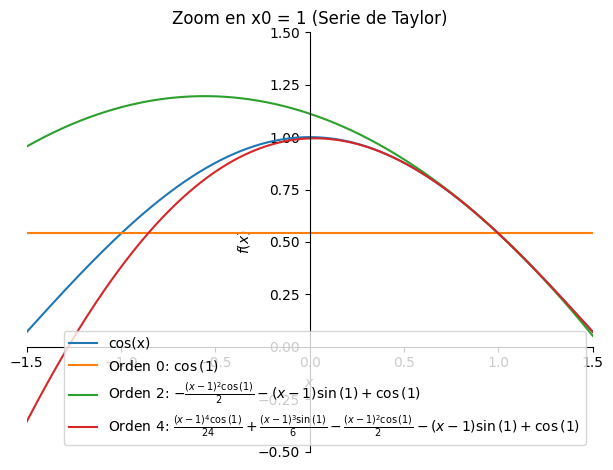

In [3]:
ordenes = [0, 2, 4] 
graficas = [f]
labels = ['cos(x)']

for n in ordenes:
    p = sp.series(f, x, 1, n+1).removeO()
    graficas.append(p)
    labels.append(f'Orden {n}: ${sp.latex(p)}$')

p_plot = sp.plot(*graficas, (x, -1.5, 1.5), 
                 xlim=(-1.5, 1.5), 
                 ylim=(-0.5, 1.5),
                 show=False, 
                 title='Zoom en x0 = 1 (Serie de Taylor)',
                 legend=True)

for i, label in enumerate(labels):
    p_plot[i].label = label

p_plot.show()

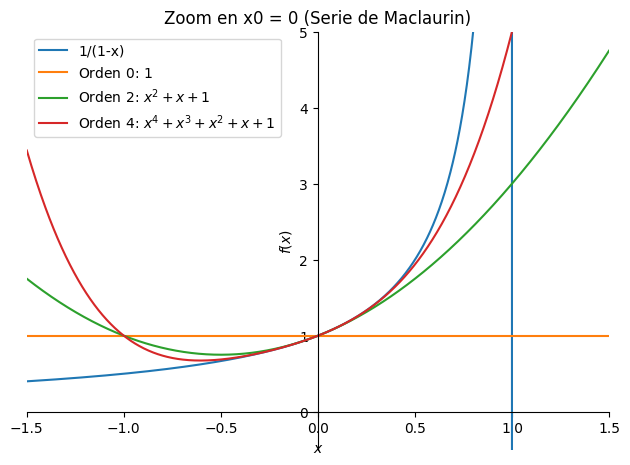

In [4]:
f2=1/(1-x)
ordenes = [0, 2, 4] 
graficas = [f2]
labels = ['1/(1-x)']

for n in ordenes:
    p = sp.series(f2, x, 0, n+1).removeO()
    graficas.append(p)
    labels.append(f'Orden {n}: ${sp.latex(p)}$')

p_plot = sp.plot(*graficas, (x, -1.5, 1.5), 
                 xlim=(-1.5, 1.5), 
                 ylim=(-0.5, 5),
                 show=False, 
                 title='Zoom en x0 = 0 (Serie de Maclaurin)', 
                 legend=True)

for i, label in enumerate(labels):
    p_plot[i].label = label

p_plot.show()

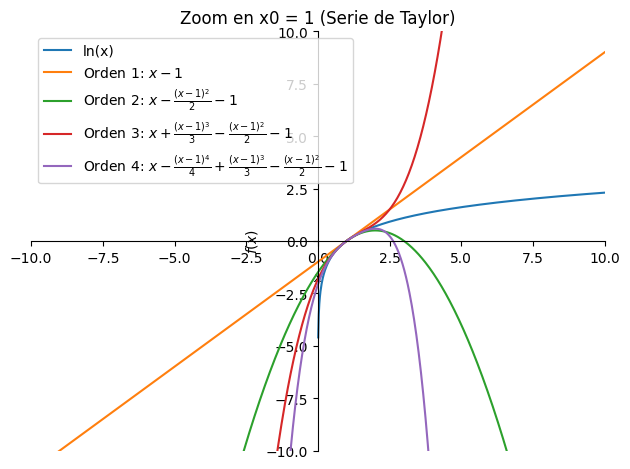

In [5]:
f3=sp.ln(x)
ordenes = [1, 2, 3, 4] 
graficas = [f3]
labels = ['ln(x)']

for n in ordenes:
    p = sp.series(f3, x, 1, n+1).removeO()
    graficas.append(p)
    labels.append(f'Orden {n}: ${sp.latex(p)}$')

p_plot = sp.plot(*graficas, (x, -10, 10), 
                 xlim=(-10, 10), 
                 ylim=(-10, 10),
                 show=False, 
                 title='Zoom en x0 = 1 (Serie de Taylor)', 
                 legend=True)

for i, label in enumerate(labels):
    p_plot[i].label = label

p_plot.show()

### **Polinomios De Lagrange**

In [ ]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

def lagrange_simbolico(puntos):
    """Recibe lista de (x_i, y_i) y devuelve P(x) simbólico."""
    x = sp.Symbol('x')
    P = sp.Integer(0)
    for i in range(len(puntos)):
        xi, yi = puntos[i]
        Li = sp.Integer(1)
        for j in range(len(puntos)):
            if j != i:
                xj = puntos[j][0]
                Li *= (x - xj) / (xi - xj)
        P += yi * Li
    return x, sp.expand(P)

## Caso 1 — $(0,0),\ (30, 0.5),\ (60, \frac{\sqrt{3}}{2}),\ (90, 1)$

Estos puntos corresponden a $\sin(x°)$ evaluado en 0°, 30°, 60° y 90°. Con 4 puntos obtenemos un polinomio de **grado 3**.

P(x) = -sqrt(3)*x**3/108000 + x**3/64800 - 7*x**2/3600 + sqrt(3)*x**2/900 - sqrt(3)*x/40 + 11*x/180
P(45) = 0.7058892896287468
sin(45°) real = 0.7071067811865475
Error: 0.0012174915578007095


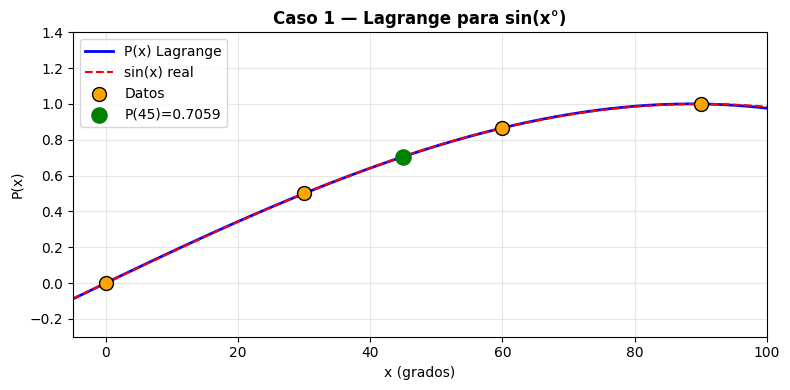

In [7]:
puntos1 = [(0, 0), (30, sp.Rational(1,2)), (60, sp.sqrt(3)/2), (90, 1)]
x, P1 = lagrange_simbolico(puntos1)

print("P(x) =", P1)
print("P(45) =", float(P1.subs(x, 45)))
print("sin(45°) real =", np.sin(np.deg2rad(45)))
print("Error:", abs(float(P1.subs(x, 45)) - np.sin(np.deg2rad(45))))

# Graficar
P1_num = sp.lambdify(x, P1, 'numpy')
x_vals = np.linspace(-5, 100, 400)

plt.figure(figsize=(8, 4))
plt.plot(x_vals, P1_num(x_vals), 'b-', linewidth=2, label='P(x) Lagrange')
plt.plot(x_vals, np.sin(np.deg2rad(x_vals)), 'r--', linewidth=1.5, label='sin(x) real')
xs = [float(p[0]) for p in puntos1]
ys = [float(p[1]) for p in puntos1]
plt.scatter(xs, ys, color='orange', s=100, zorder=5, edgecolors='black', label='Datos')
plt.scatter([45], [float(P1_num(45))], color='green', s=120, zorder=6, label=f'P(45)={float(P1_num(45)):.4f}')
plt.xlim(-5, 100); plt.ylim(-0.3, 1.4)
plt.title('Caso 1 — Lagrange para sin(x°)', fontweight='bold')
plt.xlabel('x (grados)'); plt.ylabel('P(x)'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Caso 2 — $(1,1),\ (2,2),\ (3,2)$

Con 3 puntos obtenemos un polinomio de **grado 2** (parábola).

P(x) = -x**2/2 + 5*x/2 - 1
P(2.5) = 2.125


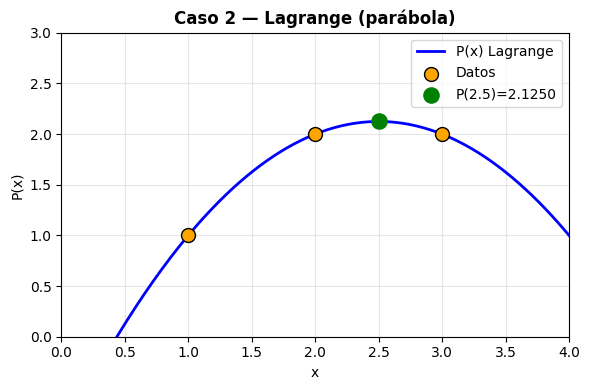

In [8]:
puntos2 = [(1, 1), (2, 2), (3, 2)]
x, P2 = lagrange_simbolico(puntos2)

print("P(x) =", P2)
print("P(2.5) =", float(P2.subs(x, 2.5)))

P2_num = sp.lambdify(x, P2, 'numpy')
x_vals = np.linspace(0, 4, 300)

plt.figure(figsize=(6, 4))
plt.plot(x_vals, P2_num(x_vals), 'b-', linewidth=2, label='P(x) Lagrange')
xs = [p[0] for p in puntos2]; ys = [p[1] for p in puntos2]
plt.scatter(xs, ys, color='orange', s=100, zorder=5, edgecolors='black', label='Datos')
plt.scatter([2.5], [float(P2_num(2.5))], color='green', s=120, zorder=6, label=f'P(2.5)={float(P2_num(2.5)):.4f}')
plt.xlim(0, 4); plt.ylim(0, 3)
plt.title('Caso 2 — Lagrange (parábola)', fontweight='bold')
plt.xlabel('x'); plt.ylabel('P(x)'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Caso 3 — $(-2,5),\ (1,7),\ (3,11),\ (7,34)$

Con 4 puntos obtenemos un polinomio de **grado 3**.

P(x) = 43*x**3/1080 + 101*x**2/540 + 793*x/1080 + 1087/180
P(2) = 8.574074074074074


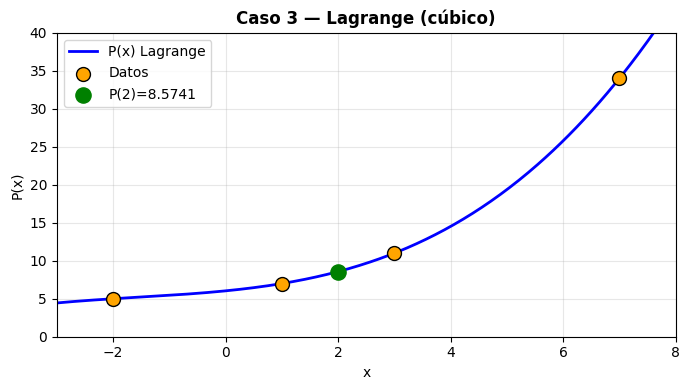

In [9]:
puntos3 = [(-2, 5), (1, 7), (3, 11), (7, 34)]
x, P3 = lagrange_simbolico(puntos3)

print("P(x) =", P3)
print("P(2) =", float(P3.subs(x, 2)))

P3_num = sp.lambdify(x, P3, 'numpy')
x_vals = np.linspace(-3, 8, 400)

plt.figure(figsize=(7, 4))
plt.plot(x_vals, P3_num(x_vals), 'b-', linewidth=2, label='P(x) Lagrange')
xs = [p[0] for p in puntos3]; ys = [p[1] for p in puntos3]
plt.scatter(xs, ys, color='orange', s=100, zorder=5, edgecolors='black', label='Datos')
plt.scatter([2], [float(P3_num(2))], color='green', s=120, zorder=6, label=f'P(2)={float(P3_num(2)):.4f}')
plt.xlim(-3, 8); plt.ylim(0, 40)
plt.title('Caso 3 — Lagrange (cúbico)', fontweight='bold')
plt.xlabel('x'); plt.ylabel('P(x)'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()